# 03 — Quantum Clustering Prototype (UBCF, Improved)

This notebook now includes:
- IQP-style entanglement after angle encoding (CNOT chain + optional StronglyEntanglingLayers)
- Trainable variational feature map (contrastive objective)
- Quantum kernel options: full-state fidelity and 2D subspace/noisy fidelity estimation
- Clustering options: kernel Lloyd baseline and optional adiabatic-inspired VQE bisection
- Model selection sweep (`K_QUANTUM` from 3 to 10) with silhouette/inertia
- Validation: silhouette, Davies–Bouldin, and per-cluster silhouette breakdown

Primary output: `quantum_user_labels.npy`

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import MDS
from sklearn.metrics import davies_bouldin_score, silhouette_samples, silhouette_score
from sklearn.preprocessing import normalize

try:
    import pennylane as qml
    from pennylane import numpy as pnp
    PENNYLANE_AVAILABLE = True
except Exception:
    PENNYLANE_AVAILABLE = False

try:
    from qiskit.circuit.library import EfficientSU2
    from qiskit.primitives import StatevectorEstimator
    from qiskit.quantum_info import SparsePauliOp
    from qiskit_algorithms import VQE
    from qiskit_algorithms.optimizers import COBYLA
    QISKIT_AVAILABLE = True
except Exception:
    QISKIT_AVAILABLE = False

IN_DIR = Path("data/processed_32m_ubcf")
OUT_DIR = Path("data/processed_32m_ubcf")

SEED = 42
N_QUBITS = 5
TARGET_DIM = 2 ** N_QUBITS
SAMPLE_USERS = 300
MAX_ITERS = 20
IQP_LAYERS = 2
VAR_MAP_STEPS = 60
VAR_MAP_LR = 0.05
K_MIN, K_MAX = 3, 10
NOISY_SHOTS = 1024
USE_SUBSPACE_KERNEL = True
USE_NOISY_SUBSPACE = True
USE_STRONG_ENTANGLING = True

if not PENNYLANE_AVAILABLE:
    raise ImportError("PennyLane is required for this notebook version.")

user_latent_full = np.load(IN_DIR / "user_latent.npy").astype(np.float32)
rng = np.random.default_rng(SEED)
sample_idx = np.sort(
    rng.choice(np.arange(len(user_latent_full)), size=min(SAMPLE_USERS, len(user_latent_full)), replace=False)
 )
X = user_latent_full[sample_idx]

if X.shape[1] < TARGET_DIM:
    X = np.pad(X, ((0, 0), (0, TARGET_DIM - X.shape[1])), mode="constant")
else:
    X = X[:, :TARGET_DIM]

X_amp = normalize(X, norm="l2", axis=1).astype(np.float32)
X_ang = X[:, :N_QUBITS]
med = np.median(X_ang, axis=0, keepdims=True)
iqr = np.subtract(*np.percentile(X_ang, [75, 25], axis=0, keepdims=True)) + 1e-8
X_ang = np.clip((X_ang - med) / iqr, -3.0, 3.0)
X_ang = ((X_ang + 3.0) / 6.0) * np.pi

print(f"PennyLane={PENNYLANE_AVAILABLE} Qiskit={QISKIT_AVAILABLE} sample={len(X)} n_qubits={N_QUBITS}")

C:\Users\acolumban\AppData\Local\Temp\ipykernel_20444\1486744750.py:17: DeprecationWarning: Using Qiskit with Python 3.9 is deprecated as of the 2.1.0 release. Support for running Qiskit with Python 3.9 will be removed in the 2.3.0 release, which coincides with when Python 3.9 goes end of life.
  from qiskit.circuit.library import EfficientSU2


PennyLane=True Qiskit=False sample=300 n_qubits=5


In [2]:
# Quantum feature-map utilities (IQP entanglement + trainable variational map)
def iqp_entanglement_chain(wires):
    for i in range(len(wires) - 1):
        qml.CNOT(wires=[wires[i], wires[i + 1]])

def amp_state(v):
    vec = v.astype(np.complex64)
    return vec / (np.linalg.norm(vec) + 1e-12)

dev_state = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev_state, interface="autograd")
def variational_angle_state(theta_vec, weights, use_strong=True):
    for wire in range(N_QUBITS):
        qml.RY(theta_vec[wire], wires=wire)
    iqp_entanglement_chain(list(range(N_QUBITS)))
    if use_strong:
        qml.StronglyEntanglingLayers(weights, wires=list(range(N_QUBITS)))
    else:
        for layer in range(weights.shape[0]):
            for wire in range(N_QUBITS):
                qml.RY(weights[layer, wire, 0], wires=wire)
                qml.RZ(weights[layer, wire, 1], wires=wire)
            iqp_entanglement_chain(list(range(N_QUBITS)))
    return qml.state()

def fidelity(a, b):
    return float(np.abs(np.vdot(a, b)) ** 2)

def fidelity_autograd(a, b):
    overlap = qml.math.sum(qml.math.conj(a) * b)
    return qml.math.real(overlap * qml.math.conj(overlap))

def train_variational_map(X_ang_input, X_amp_input, steps=VAR_MAP_STEPS, lr=VAR_MAP_LR, seed=SEED):
    rng_local = np.random.default_rng(seed)
    subset_n = min(48, len(X_ang_input))
    subset_idx = np.sort(rng_local.choice(np.arange(len(X_ang_input)), size=subset_n, replace=False))

    sim = X_amp_input[subset_idx] @ X_amp_input[subset_idx].T
    hi = np.quantile(sim, 0.75)
    lo = np.quantile(sim, 0.25)

    pos_candidates = np.argwhere(sim >= hi)
    neg_candidates = np.argwhere(sim <= lo)
    pos_candidates = pos_candidates[pos_candidates[:, 0] < pos_candidates[:, 1]]
    neg_candidates = neg_candidates[neg_candidates[:, 0] < neg_candidates[:, 1]]

    pair_budget = min(64, len(pos_candidates), len(neg_candidates))
    if pair_budget == 0:
        pair_budget = min(16, len(pos_candidates))
        neg_budget = min(16, len(neg_candidates))
    else:
        neg_budget = pair_budget

    pos_pick = pos_candidates[rng_local.choice(len(pos_candidates), size=pair_budget, replace=False)] if len(pos_candidates) else np.empty((0, 2), dtype=int)
    neg_pick = neg_candidates[rng_local.choice(len(neg_candidates), size=neg_budget, replace=False)] if len(neg_candidates) else np.empty((0, 2), dtype=int)

    weights = pnp.array(
        0.01 * rng_local.standard_normal((IQP_LAYERS, N_QUBITS, 3)),
        requires_grad=True,
    )
    optimizer = qml.AdamOptimizer(stepsize=lr)
    margin = 0.35

    def loss_fn(w):
        loss_val = 0.0
        for ii, jj in pos_pick:
            si = variational_angle_state(X_ang_input[subset_idx[ii]], w, use_strong=USE_STRONG_ENTANGLING)
            sj = variational_angle_state(X_ang_input[subset_idx[jj]], w, use_strong=USE_STRONG_ENTANGLING)
            f = fidelity_autograd(si, sj)
            loss_val = loss_val + (1.0 - f) ** 2
        for ii, jj in neg_pick:
            si = variational_angle_state(X_ang_input[subset_idx[ii]], w, use_strong=USE_STRONG_ENTANGLING)
            sj = variational_angle_state(X_ang_input[subset_idx[jj]], w, use_strong=USE_STRONG_ENTANGLING)
            f = fidelity_autograd(si, sj)
            loss_val = loss_val + qml.math.maximum(0.0, f - margin) ** 2
        denom = max(1, len(pos_pick) + len(neg_pick))
        return loss_val / denom

    log_every = max(1, steps // 5)
    for step in range(steps):
        weights, loss_val = optimizer.step_and_cost(loss_fn, weights)
        if (step + 1) % log_every == 0 or step == 0:
            print(f"variational_step={step+1}/{steps} loss={float(loss_val):.6f}")

    return np.array(weights, dtype=np.float32)

var_weights = train_variational_map(X_ang, X_amp)
amp_states = [amp_state(X_amp[i]) for i in range(len(X_amp))]
ang_states = [np.array(variational_angle_state(X_ang[i], var_weights, use_strong=USE_STRONG_ENTANGLING), dtype=np.complex64) for i in range(len(X_ang))]

print("Trained variational map and generated quantum states.")

variational_step=1/60 loss=0.214307
variational_step=12/60 loss=0.214307
variational_step=24/60 loss=0.214307
variational_step=36/60 loss=0.214307
variational_step=48/60 loss=0.214307
variational_step=60/60 loss=0.214307
Trained variational map and generated quantum states.


In [3]:
# Quantum kernel computation (full + optional 2D subspace/noisy projection)
def build_full_fidelity_kernel(amp_states_in, ang_states_in, alpha=0.5):
    n_points = len(amp_states_in)
    kernel_out = np.eye(n_points, dtype=np.float32)
    for i in range(n_points):
        for j in range(i + 1, n_points):
            f_amp = fidelity(amp_states_in[i], amp_states_in[j])
            f_ang = fidelity(ang_states_in[i], ang_states_in[j])
            kij = alpha * f_amp + (1.0 - alpha) * f_ang
            kernel_out[i, j] = kij
            kernel_out[j, i] = kij
    return kernel_out

dev_subspace_analytic = qml.device("default.qubit", wires=1)
dev_subspace_noisy = qml.device("default.mixed", wires=1, shots=NOISY_SHOTS)

@qml.qnode(dev_subspace_analytic)
def subspace_overlap_analytic(theta_a, theta_b):
    qml.RY(theta_a, wires=0)
    qml.RY(-theta_b, wires=0)
    return qml.probs(wires=[0])

@qml.qnode(dev_subspace_noisy)
def subspace_overlap_noisy(theta_a, theta_b):
    qml.RY(theta_a, wires=0)
    qml.DepolarizingChannel(0.01, wires=0)
    qml.RY(-theta_b, wires=0)
    qml.DepolarizingChannel(0.01, wires=0)
    return qml.probs(wires=[0])

def vec2theta(v2):
    v2 = np.asarray(v2, dtype=np.float64)
    norm = np.linalg.norm(v2) + 1e-12
    z = v2 / norm
    c0 = np.clip(z[0], -1.0, 1.0)
    return float(2.0 * np.arccos(c0))

def subspace_fidelity(v_a, v_b, noisy=False):
    t_a = vec2theta(v_a)
    t_b = vec2theta(v_b)
    probs = subspace_overlap_noisy(t_a, t_b) if noisy else subspace_overlap_analytic(t_a, t_b)
    return float(probs[0])

def _build_subspace_kernel_exact(X_in, noisy=False):
    n_points, d = X_in.shape
    if d % 2 != 0:
        X_local = np.pad(X_in, ((0, 0), (0, 1)), mode="constant")
    else:
        X_local = X_in
    subspaces = X_local.reshape(X_local.shape[0], -1, 2)
    kernel_out = np.eye(n_points, dtype=np.float32)
    for i in range(n_points):
        for j in range(i + 1, n_points):
            vals = [subspace_fidelity(subspaces[i, s], subspaces[j, s], noisy=noisy) for s in range(subspaces.shape[1])]
            kij = float(np.mean(vals))
            kernel_out[i, j] = kij
            kernel_out[j, i] = kij
    return kernel_out

def build_subspace_kernel(X_in, noisy=False, seed=SEED):
    n_points = X_in.shape[0]
    if not noisy or n_points <= 120:
        return _build_subspace_kernel_exact(X_in, noisy=noisy)

    K_analytic = _build_subspace_kernel_exact(X_in, noisy=False)
    rng_local = np.random.default_rng(seed)
    pairs = []
    for _ in range(min(400, n_points * 2)):
        i, j = rng_local.integers(0, n_points, size=2)
        if i < j:
            pairs.append((int(i), int(j)))

    if len(pairs) == 0:
        return K_analytic

    if X_in.shape[1] % 2 != 0:
        X_local = np.pad(X_in, ((0, 0), (0, 1)), mode="constant")
    else:
        X_local = X_in
    subspaces = X_local.reshape(X_local.shape[0], -1, 2)

    noisy_vals = []
    analytic_vals = []
    for i, j in pairs:
        noisy_ij = float(np.mean([subspace_fidelity(subspaces[i, s], subspaces[j, s], noisy=True) for s in range(subspaces.shape[1])]))
        analytic_ij = float(np.mean([subspace_fidelity(subspaces[i, s], subspaces[j, s], noisy=False) for s in range(subspaces.shape[1])]))
        noisy_vals.append(noisy_ij)
        analytic_vals.append(max(analytic_ij, 1e-6))

    correction = float(np.clip(np.mean(np.array(noisy_vals) / np.array(analytic_vals)), 0.5, 1.0))
    K_noisy_approx = np.clip(K_analytic * correction, 0.0, 1.0)
    np.fill_diagonal(K_noisy_approx, 1.0)
    print(f"Noisy subspace correction factor (sampled): {correction:.4f}")
    return K_noisy_approx.astype(np.float32)

def center_kernel(K):
    n_points = K.shape[0]
    H = np.eye(n_points, dtype=np.float64) - np.ones((n_points, n_points), dtype=np.float64) / n_points
    return (H @ K @ H).astype(np.float64)

def nearest_psd(K):
    K_sym = 0.5 * (K + K.T)
    eigvals, eigvecs = np.linalg.eigh(K_sym)
    eigvals = np.clip(eigvals, 0.0, None)
    K_psd = (eigvecs * eigvals) @ eigvecs.T
    return 0.5 * (K_psd + K_psd.T)

def normalize_kernel_diagonal(K):
    diag = np.sqrt(np.clip(np.diag(K), 1e-12, None))
    return (K / diag[:, None]) / diag[None, :]

alpha_grid = [0.25, 0.5, 0.75]
best_kernel = None
best_score = -np.inf
best_alpha = None

for alpha in alpha_grid:
    K_full = build_full_fidelity_kernel(amp_states, ang_states, alpha=alpha).astype(np.float64)
    if USE_SUBSPACE_KERNEL:
        K_sub = build_subspace_kernel(X, noisy=USE_NOISY_SUBSPACE).astype(np.float64)
        K_mix = 0.5 * K_full + 0.5 * K_sub
    else:
        K_mix = K_full

    K_proc = center_kernel(K_mix)
    K_proc = nearest_psd(K_proc)
    K_proc = normalize_kernel_diagonal(K_proc)
    K_proc = np.clip(K_proc, -1.0, 1.0)

    trial_score = float(np.mean(np.diag(K_proc)))
    if trial_score > best_score:
        best_score = trial_score
        best_alpha = alpha
        best_kernel = K_proc

kernel = best_kernel.astype(np.float32)
kernel_poly = np.power(np.clip(kernel, -1.0, 1.0), 2.0).astype(np.float32)
np.savez_compressed(
    IN_DIR / "user_kernel_matrix.npz",
    kernel=kernel,
    kernel_poly=kernel_poly,
    sample_idx=sample_idx,
    alpha=best_alpha,
    use_subspace=USE_SUBSPACE_KERNEL,
    use_noisy_subspace=USE_NOISY_SUBSPACE,
    noisy_shots=NOISY_SHOTS,
 )
print(f"Kernel built: shape={kernel.shape}, alpha={best_alpha}, subspace={USE_SUBSPACE_KERNEL}, noisy={USE_NOISY_SUBSPACE}")

Noisy subspace correction factor (sampled): 0.9991
Noisy subspace correction factor (sampled): 0.9994
Noisy subspace correction factor (sampled): 0.9992
Kernel built: shape=(300, 300), alpha=0.25, subspace=True, noisy=True


In [4]:
# Clustering + model selection (kernel sweep, k sweep, adiabatic option)
def kernel_to_distance(K):
    diag = np.diag(K)
    d2 = np.clip(diag[:, None] + diag[None, :] - 2.0 * K, 0.0, None)
    return np.sqrt(d2, dtype=np.float64)

def kernel_kmeans(K, k, max_iters=MAX_ITERS, n_init=10, seed=SEED):
    rng_local = np.random.default_rng(seed)
    n_points = K.shape[0]
    best_labels = None
    best_obj = np.inf

    for _ in range(n_init):
        labels = rng_local.integers(0, k, size=n_points, endpoint=False).astype(np.int32)
        for _ in range(max_iters):
            prev = labels.copy()
            dist = np.zeros((n_points, k), dtype=np.float64)
            for c in range(k):
                members = np.where(labels == c)[0]
                if len(members) == 0:
                    dist[:, c] = np.inf
                    continue
                K_ic = K[:, members]
                term2 = (2.0 / len(members)) * K_ic.sum(axis=1)
                K_cc = K[np.ix_(members, members)]
                term3 = K_cc.sum() / (len(members) ** 2)
                dist[:, c] = np.diag(K) - term2 + term3
            labels = np.argmin(dist, axis=1).astype(np.int32)
            if np.array_equal(prev, labels):
                break
        obj = np.sum(np.min(dist, axis=1))
        if obj < best_obj:
            best_obj = float(obj)
            best_labels = labels.copy()

    return best_labels, best_obj

def _vqe_binary_cut(distance_sub, seed=SEED):
    n_sub = distance_sub.shape[0]
    if not QISKIT_AVAILABLE or n_sub < 2:
        return np.arange(n_sub) % 2

    paulis = []
    coeffs = []
    for i in range(n_sub):
        for j in range(i + 1, n_sub):
            w = float(distance_sub[i, j])
            if w <= 0:
                continue
            z = ["I"] * n_sub
            z[i] = "Z"
            z[j] = "Z"
            paulis.append("".join(z[::-1]))
            coeffs.append(w)

    if not paulis:
        return np.arange(n_sub) % 2

    hamiltonian = SparsePauliOp(paulis, coeffs=coeffs)
    ansatz = EfficientSU2(num_qubits=n_sub, reps=2, entanglement="linear")
    optimizer = COBYLA(maxiter=80)
    estimator = StatevectorEstimator()
    vqe = VQE(estimator=estimator, ansatz=ansatz, optimizer=optimizer)
    result = vqe.compute_minimum_eigenvalue(hamiltonian)

    from qiskit.quantum_info import Statevector
    state = Statevector(ansatz.assign_parameters(result.optimal_point))
    bit_idx = int(np.argmax(np.abs(state.data) ** 2))
    bitstring = np.binary_repr(bit_idx, width=n_sub)
    labels = np.array([int(b) for b in bitstring[::-1]], dtype=np.int32)
    if labels.min() == labels.max():
        labels[::2] = 0
        labels[1::2] = 1
    return labels

def adiabatic_quantum_kmeans_vqe(K, k, seed=SEED):
    rng_local = np.random.default_rng(seed)
    n_points = K.shape[0]
    dmat_local = kernel_to_distance(K)

    anchor_n = min(max(k * 2, N_QUBITS), n_points)
    anchors = np.sort(rng_local.choice(np.arange(n_points), size=anchor_n, replace=False))
    anchor_clusters = [anchors.copy()]

    while len(anchor_clusters) < k:
        sizes = np.array([len(c) for c in anchor_clusters])
        pick = int(np.argmax(sizes))
        block = anchor_clusters.pop(pick)
        if len(block) < 4:
            anchor_clusters.append(block)
            if len(anchor_clusters) == len(sizes):
                break
            continue

        if len(block) > N_QUBITS:
            sub_idx = np.sort(rng_local.choice(block, size=N_QUBITS, replace=False))
        else:
            sub_idx = block
        D_sub = dmat_local[np.ix_(sub_idx, sub_idx)]
        cut_labels = _vqe_binary_cut(D_sub, seed=seed)

        left = sub_idx[cut_labels == 0]
        right = sub_idx[cut_labels == 1]
        if len(left) == 0 or len(right) == 0:
            half = len(sub_idx) // 2
            left, right = sub_idx[:half], sub_idx[half:]
        anchor_clusters.append(left)
        anchor_clusters.append(right)
        anchor_clusters = [c for c in anchor_clusters if len(c) > 0]
        if len(anchor_clusters) >= k:
            break

    while len(anchor_clusters) < k:
        anchor_clusters.append(anchor_clusters[len(anchor_clusters) % len(anchor_clusters)])

    medoids = []
    for cluster in anchor_clusters[:k]:
        D = dmat_local[np.ix_(cluster, cluster)]
        medoid = int(cluster[np.argmin(D.mean(axis=1))])
        medoids.append(medoid)
    medoids = np.array(medoids, dtype=np.int32)

    assign_dist = dmat_local[:, medoids]
    labels = np.argmin(assign_dist, axis=1).astype(np.int32)
    return labels

def evaluate_labels(K, labels):
    dmat_local = kernel_to_distance(K)
    if len(np.unique(labels)) < 2:
        return {"silhouette": -1.0, "inertia": np.inf, "dmat": dmat_local}
    sil = float(silhouette_score(dmat_local, labels, metric="precomputed"))
    inertia = float(np.sum([dmat_local[i, np.where(labels == labels[i])[0]].mean() for i in range(len(labels))]))
    return {"silhouette": sil, "inertia": inertia, "dmat": dmat_local}

kernels = {"fidelity": kernel, "fidelity_poly2": kernel_poly}
methods = ["kernel_kmeans"]
if QISKIT_AVAILABLE:
    methods.append("adiabatic_vqe")

results = []
for kernel_name, K_use in kernels.items():
    for method in methods:
        for k_val in range(K_MIN, K_MAX + 1):
            if method == "adiabatic_vqe":
                labels = adiabatic_quantum_kmeans_vqe(K_use, k_val, seed=SEED)
                objective = np.nan
            else:
                labels, objective = kernel_kmeans(K_use, k=k_val, max_iters=MAX_ITERS, n_init=20, seed=SEED)
            metrics = evaluate_labels(K_use, labels)
            results.append({
                "kernel": kernel_name,
                "method": method,
                "k": k_val,
                "silhouette": metrics["silhouette"],
                "inertia": metrics["inertia"],
                "objective": objective,
                "labels": labels,
                "dmat": metrics["dmat"],
            })

valid_results = [r for r in results if np.isfinite(r["silhouette"]) and r["silhouette"] > -1.0]
best = sorted(valid_results, key=lambda r: (r["silhouette"], -r["inertia"]), reverse=True)[0]

best_kernel_name = best["kernel"]
best_method = best["method"]
best_k = int(best["k"])
quantum_user_labels = best["labels"].astype(np.int32)
dmat = best["dmat"]
np.save(OUT_DIR / "quantum_user_labels.npy", quantum_user_labels)

print(f"Best method={best_method} kernel={best_kernel_name} k={best_k}")
print("Saved: quantum_user_labels.npy")

Best method=kernel_kmeans kernel=fidelity k=7
Saved: quantum_user_labels.npy


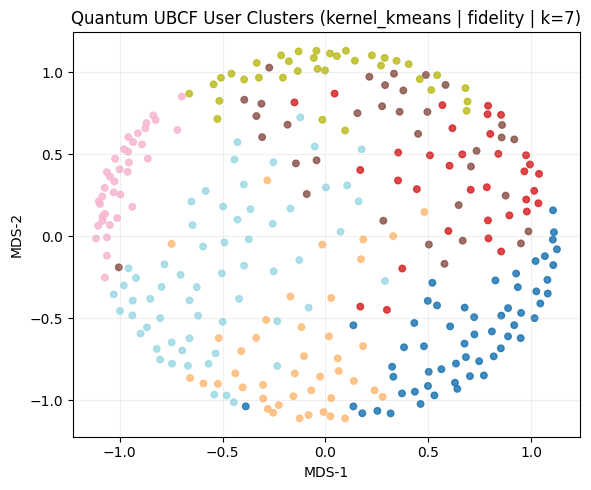

Silhouette Score: 0.0868
Davies-Bouldin Score: 1.6134
Per-cluster silhouette: {0: 0.06734222090318977, 1: 0.06215506517868138, 2: 0.055955702763115664, 3: 0.06910727519274307, 4: 0.30131649496831364, 5: 0.08363563931464708, 6: 0.02064427581986631}
Saved: quantum_user_labels.npy and user_kernel_matrix.npz


In [5]:
# Visualization and validation metrics
xy = MDS(n_components=2, dissimilarity="precomputed", random_state=SEED).fit_transform(dmat)
sil_score = float(silhouette_score(dmat, quantum_user_labels, metric="precomputed"))
sil_vals = silhouette_samples(dmat, quantum_user_labels, metric="precomputed")
clusters = np.unique(quantum_user_labels)
cluster_breakdown = {int(c): float(np.mean(sil_vals[quantum_user_labels == c])) for c in clusters}
db_score = float(davies_bouldin_score(xy, quantum_user_labels))

plt.figure(figsize=(6, 5))
plt.scatter(xy[:, 0], xy[:, 1], c=quantum_user_labels, s=22, cmap="tab20", alpha=0.85)
plt.title(f"Quantum UBCF User Clusters ({best_method} | {best_kernel_name} | k={best_k})")
plt.xlabel("MDS-1")
plt.ylabel("MDS-2")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

print(f"Silhouette Score: {sil_score:.4f}")
print(f"Davies-Bouldin Score: {db_score:.4f}")
print("Per-cluster silhouette:", cluster_breakdown)
print("Saved: quantum_user_labels.npy and user_kernel_matrix.npz")